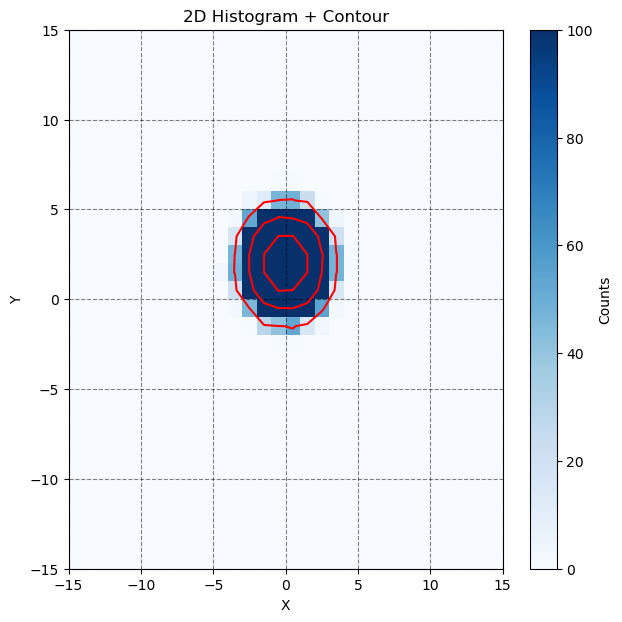

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate data
np.random.seed(0)
X = np.random.normal(0, 1, 100000)
Y = np.random.normal(2, 1, 100000)

plt.figure(figsize=(7,7))

# 2D histogram
H, xedges, yedges, img = plt.hist2d(
    X, Y,
    bins=30,
    range=[[-15,15],[-15,15]],
    cmap='Blues',
    vmin=0,
    vmax=100
)

plt.colorbar(label='Counts')

# Prepare grid for contour
H = H.T
xcenters = (xedges[:-1] + xedges[1:]) / 2
ycenters = (yedges[:-1] + yedges[1:]) / 2
Xc, Yc = np.meshgrid(xcenters, ycenters)

# Compute probability levels
Hflat = H.flatten()
Hsorted = np.sort(Hflat)[::-1]
cdf = np.cumsum(Hsorted)
cdf /= cdf[-1]

levels = []
for p in [0.68, 0.95, 0.997]:
    levels.append(Hsorted[np.searchsorted(cdf, p)])

levels = sorted(levels)

# Plot contours
plt.contour(Xc, Yc, H, levels=levels, colors='red')

# Axis limits
plt.xlim(-15,15)
plt.ylim(-15,15)

# Labels
plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Histogram + Contour")

# Grid
plt.grid(True, linestyle="--", color="black", alpha=0.5)

plt.show()

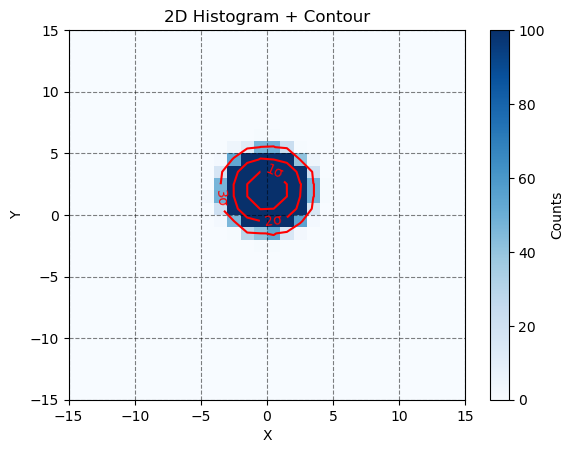

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Generate Gaussian data
np.random.seed(0)
X = np.random.normal(0, 1, 100000)
Y = np.random.normal(2, 1, 100000)

# 2D histogram
H, xedges, yedges, img = plt.hist2d(
    X, Y,
    bins=30,
    range=[[-15,15],[-15,15]],
    cmap="Blues",
    vmin=0,
    vmax=100
)

plt.colorbar(label="Counts")

# Prepare grid for contour
H = H.T
x = (xedges[:-1] + xedges[1:]) / 2
y = (yedges[:-1] + yedges[1:]) / 2
Xc, Yc = np.meshgrid(x, y)
Z = np.exp(-((Xc)**2 + (Yc-2)**2)/2)

# Find probability levels (1σ,2σ,3σ)
h = np.sort(H.ravel())[::-1]
cdf = np.cumsum(h) / np.sum(h)
levels = [h[np.searchsorted(cdf, p)] for p in [0.68, 0.95, 0.997]]

# Draw contours
plt.contour(Xc, Yc, Z, levels=sorted(levels), colors="red")

plt.xlim(-15,15)
plt.ylim(-15,15)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Histogram + Contour")
plt.grid(True, linestyle="--", color="black", alpha=0.5)

CS = plt.contour(Xc, Yc, H, levels=sorted(levels), colors="red")
plt.clabel(CS, fmt={levels[0]:"1σ", levels[1]:"2σ", levels[2]:"3σ"})

plt.show()